# People Analytics: Simulación de A/B Testing y Análisis Económico

Este notebook realiza la simulación de asignación aleatoria de proveedores por cluster, evalúa su efectividad y actualiza el análisis financiero del proyecto.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Carga de Datos y Asignación de Proveedores (A/B Testing)

Asignaremos a los colaboradores de cada cluster aleatoriamente a uno de los 3 proveedores (A, B, C).

In [5]:
df = pd.read_csv('../data/dataset_salida.csv')

# Simulación de asignación aleatoria estratificada por cluster
np.random.seed(42)
df['proveedor'] = df.groupby('cluster')['cluster'].transform(lambda x: np.random.choice(['Proveedor A', 'Proveedor B', 'Proveedor C'], len(x)))

print("Distribución de colaboradores por proveedor y cluster:")
print(pd.crosstab(df['cluster'], df['proveedor']))

Distribución de colaboradores por proveedor y cluster:
proveedor  Proveedor A  Proveedor B  Proveedor C
cluster                                         
0                  676          633          630
1                  338          352          310
2                  724          655          682


## 2. Simulación de Efectividad (Conocimiento)

Simularemos que los proveedores tienen impactos distintos en el resultado del aprendizaje. 
Por ejemplo, el Proveedor A es más caro pero más efectivo.

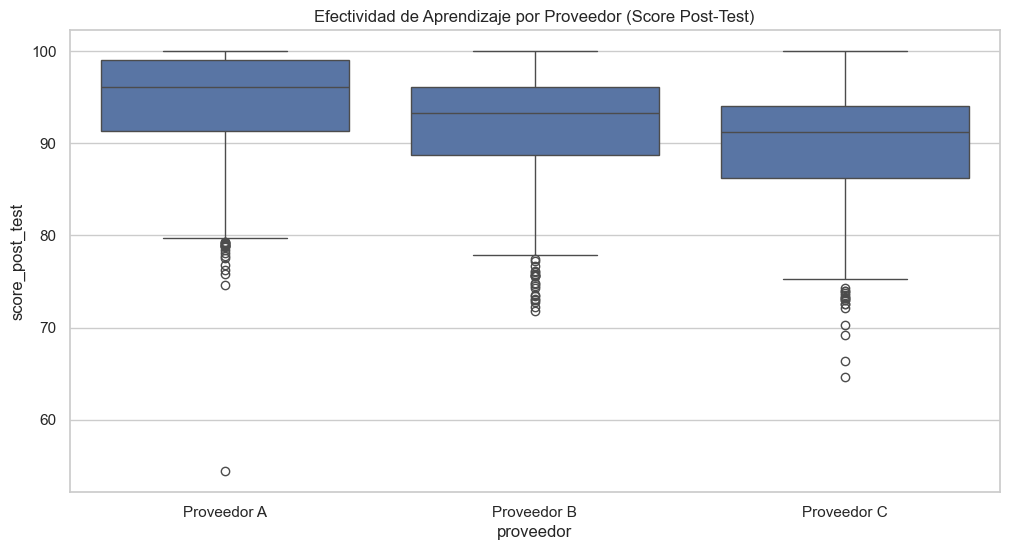

In [6]:
# Ajuste de scores basado en el proveedor (Efecto del tratamiento)
efecto_proveedor = {
    'Proveedor A': 5.0,  # Aumenta el score en 5 puntos promedio
    'Proveedor B': 2.0,  
    'Proveedor C': 0.0   
}

df['score_post_test'] = df.apply(lambda x: x['resultado_capacitacion_pci'] + efecto_proveedor[x['proveedor']] + np.random.normal(0, 2), axis=1)
df['score_post_test'] = df['score_post_test'].clip(0, 100)

plt.figure(figsize=(12, 6))
sns.boxplot(x='proveedor', y='score_post_test', data=df, order=['Proveedor A', 'Proveedor B', 'Proveedor C'])
plt.title('Efectividad de Aprendizaje por Proveedor (Score Post-Test)')
plt.show()

## 3. Análisis Económico Actualizado con Reducción de Riesgo

Incorporamos el cálculo de reducción de riesgo basado en el score promedio de cada proveedor.

In [21]:
def calcular_riesgo_multa(df,
                          var_test = 'score_post_test',
                          incremento_prob_por_punto = 0.0001,
                          umbral_score = 80,
                          prob_reputacional = 0.05,
                          costo_multa = 10000,
                          costo_reputacional = 20000,
                          prob_multa = 0,
                          forgiveness = 5):
    """
    Calcula la probabilidad de multa y el costo esperado basado en el score.

    - Score >= 80: probabilidad base mínima
    - Score < 80: aumenta 0.01% por cada punto bajo 80
    """
    n_bajo_score = df[df[var_test]< umbral_score].shape[0]

    if n_bajo_score < forgiveness:
        puntos_deficit = 0
    else:
        puntos_deficit = (umbral_score - df[df[var_test]< umbral_score][var_test]).sum()

    # Probabilidad de multa
    prob_multa = prob_multa + puntos_deficit * incremento_prob_por_punto * n_bajo_score

    # Costo esperado de multa
    costo_esp_multa = prob_multa * costo_multa

    # Costo esperado reputacional (solo si hay multa)
    costo_esp_reputacional = prob_multa * prob_reputacional * costo_reputacional

    # Costo total esperado anual
    costo_total_riesgo = costo_esp_multa + costo_esp_reputacional

    return {
        'prob_multa': prob_multa,
        'costo_esp_multa': costo_esp_multa,
        'costo_esp_reputacional': costo_esp_reputacional,
        'costo_total_riesgo_anual': costo_total_riesgo
    }

In [28]:
# Parámetros financieros (UF)
n_colaboradores = 5000
tarifa_incremental = 0.5
tasa_reevaluacion = 0.05
tasa_descuento = 0.15
factor_anualidad = sum([1 / (1 + tasa_descuento) ** i for i in range(1, 4)])

# Parámetros de riesgo
costo_multa = 10000  # UF
costo_reputacional = 20000  # UF
prob_reputacional = 0.05  # 5% si hay multa
umbral_score = 80  # Score mínimo ideal
incremento_prob_por_punto = 0.00001  # 0.01% por cada punto bajo 80

costos_base = {
    'Proveedor A': 100,
    'Proveedor B': 80,
    'Proveedor C': 70
}


analisis_final = []

for prov in ['Proveedor A', 'Proveedor B', 'Proveedor C']:
    score_medio = df[df['proveedor'] == prov]['score_post_test'].mean()

    print(f"N colaboradores con Score bajo {umbral_score}  :{n_colaboradores_con_bajo_score}")
    # Cálculo de costo directo anual
    costo_directo_anual = costos_base[prov] + (n_colaboradores * tarifa_incremental) + (
                n_colaboradores * tasa_reevaluacion * tarifa_incremental)

    # Cálculo de riesgo
    riesgo = calcular_riesgo_multa(df[df['proveedor'] == prov], prob_reputacional=prob_reputacional, costo_multa=costo_multa, costo_reputacional=costo_reputacional, incremento_prob_por_punto = incremento_prob_por_punto, umbral_score=umbral_score)

    # Costo total anual (directo + riesgo esperado)
    costo_total_anual = costo_directo_anual + riesgo['costo_total_riesgo_anual']

    # VPN a 3 años
    vpn_costo_directo = costo_directo_anual * factor_anualidad
    vpn_costo_riesgo = riesgo['costo_total_riesgo_anual'] * factor_anualidad
    vpn_total = vpn_costo_directo + vpn_costo_riesgo

    analisis_final.append({
        'Proveedor': prov,
        'Score Promedio': score_medio,
        'Prob. Multa (%)': riesgo['prob_multa'] * 100,
        'Costo Directo Anual (UF)': costo_directo_anual,
        'Costo Riesgo Anual (UF)': riesgo['costo_total_riesgo_anual'],
        'Costo Total Anual (UF)': costo_total_anual,
        'VPN Directo 3 años (UF)': vpn_costo_directo,
        'VPN Riesgo 3 años (UF)': vpn_costo_riesgo,
        'VPN Total 3 años (UF)': vpn_total
    })

df_economico = pd.DataFrame(analisis_final)
df_economico


N colaboradores con Score bajo 80  :23
N colaboradores con Score bajo 80  :23
N colaboradores con Score bajo 80  :23


,Proveedor,Score Promedio,Prob. Multa (%),Costo Directo Anual (UF),Costo Riesgo Anual (UF),Costo Total Anual (UF),VPN Directo 3 años (UF),VPN Riesgo 3 años (UF),VPN Total 3 años (UF)
0,Proveedor A,94.589700,1.413421,2725.0,155.476341,2880.476341,6221.788444,354.987486,6576.775930
1,Proveedor B,92.117175,6.898248,2705.0,758.807283,3463.807283,6176.123942,1732.527847,7908.651789
2,Proveedor C,90.023527,21.085479,2695.0,2319.402646,5014.402646,6153.291691,5295.718379,11449.010069


## 4. Visualización del Análisis Costo-Beneficio

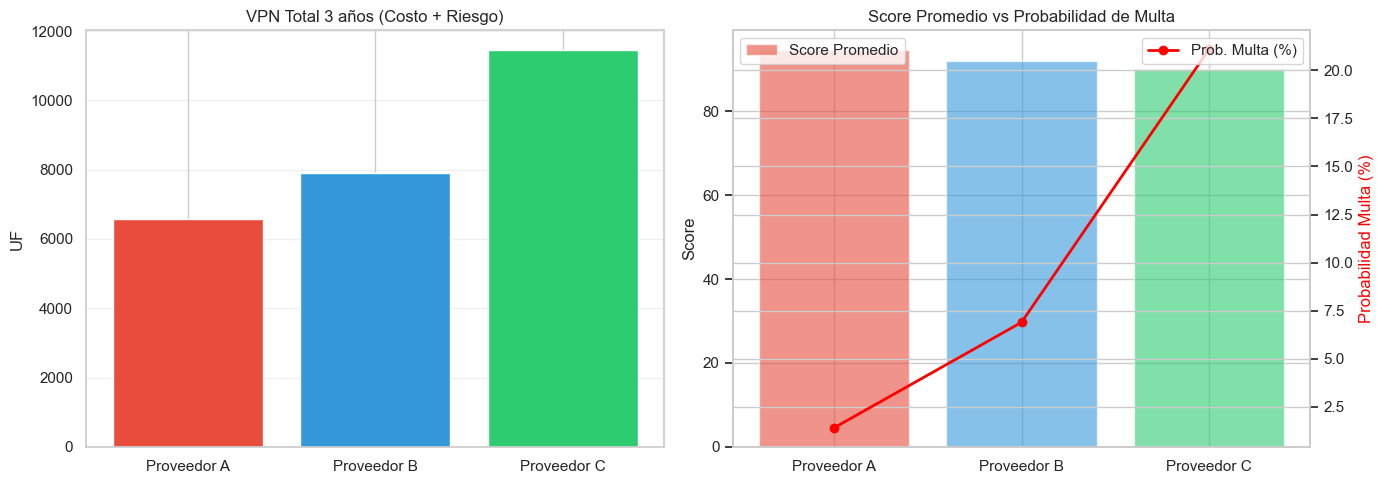


=== RESUMEN EJECUTIVO ===

  Proveedor  Score Promedio  VPN Total 3 años (UF)
Proveedor A       94.589700            6576.775930
Proveedor B       92.117175            7908.651789
Proveedor C       90.023527           11449.010069

✓ Proveedor óptimo: Proveedor A


In [29]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: VPN Total
axes[0].bar(df_economico['Proveedor'], df_economico['VPN Total 3 años (UF)'], color=['#E74C3C', '#3498DB', '#2ECC71'])
axes[0].set_title('VPN Total 3 años (Costo + Riesgo)')
axes[0].set_ylabel('UF')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Score vs Probabilidad de Multa
ax2 = axes[1].twinx()
axes[1].bar(df_economico['Proveedor'], df_economico['Score Promedio'], color=['#E74C3C', '#3498DB', '#2ECC71'],
            alpha=0.6, label='Score Promedio')
ax2.plot(df_economico['Proveedor'], df_economico['Prob. Multa (%)'], color='red', marker='o', linewidth=2,
         label='Prob. Multa (%)')
axes[1].set_title('Score Promedio vs Probabilidad de Multa')
axes[1].set_ylabel('Score')
ax2.set_ylabel('Probabilidad Multa (%)', color='red')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Resumen ejecutivo
print("\n=== RESUMEN EJECUTIVO ===\n")
print(df_economico[['Proveedor', 'Score Promedio', 'VPN Total 3 años (UF)']].to_string(index=False))
print(f"\n✓ Proveedor óptimo: {df_economico.loc[df_economico['VPN Total 3 años (UF)'].idxmin(), 'Proveedor']}")

## 5. Conclusiones Actualizadas

Con el modelo de reducción de riesgo incorporado:

1. **Proveedor A**: Mayor score (menor riesgo) pero mayor costo directo
2. **Proveedor C**: Menor costo directo pero mayor exposición al riesgo
3. **VPN Total**: Considera tanto costos directos como el valor presente del riesgo evitado

**Recomendación basada en VPN Total mínimo considerando riesgo normativo.**
